## Defense CatBoost — Adv from ResDNN + LSTM Scaled-Space

- **Eval**: adv từ `adv_eval/resdnn_sc/` + `adv_eval/lstm_sc/` + `adv_eval/cat/` (test set, scaled-space)
- **AT training**: adv từ `adv_training/resdnn_sc/` + `adv_training/lstm_sc/` (train set, scaled-space ResDNN & LSTM)
- So sánh CAT trước và sau AT (cross-model diversity)

### 1. Import packages

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import os
import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import CatBoostARTClassifier

### 2. Load model and test data

In [3]:
cat_model = joblib.load('../../../training/models/framework_cat_TVAE.pkl')

df_test = pd.read_csv('../../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

classifier = CatBoostARTClassifier(
    model=cat_model,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
)

predictions = np.argmax(classifier.predict(X_test), axis=1)
accuracy = accuracy_score(y_test, predictions)
print(f'CAT Original Accuracy: {accuracy * 100:.2f}%')

CAT Original Accuracy: 85.21%


In [4]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100
    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'CAT {attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

### 3. Evaluate baseline CAT on adv samples (before AT)

--- ResDNN-SC FGSM (before AT) ---
Accuracy: 40.78%
Precision: 43.70%
Recall: 40.78%
F1 Score: 0.3677


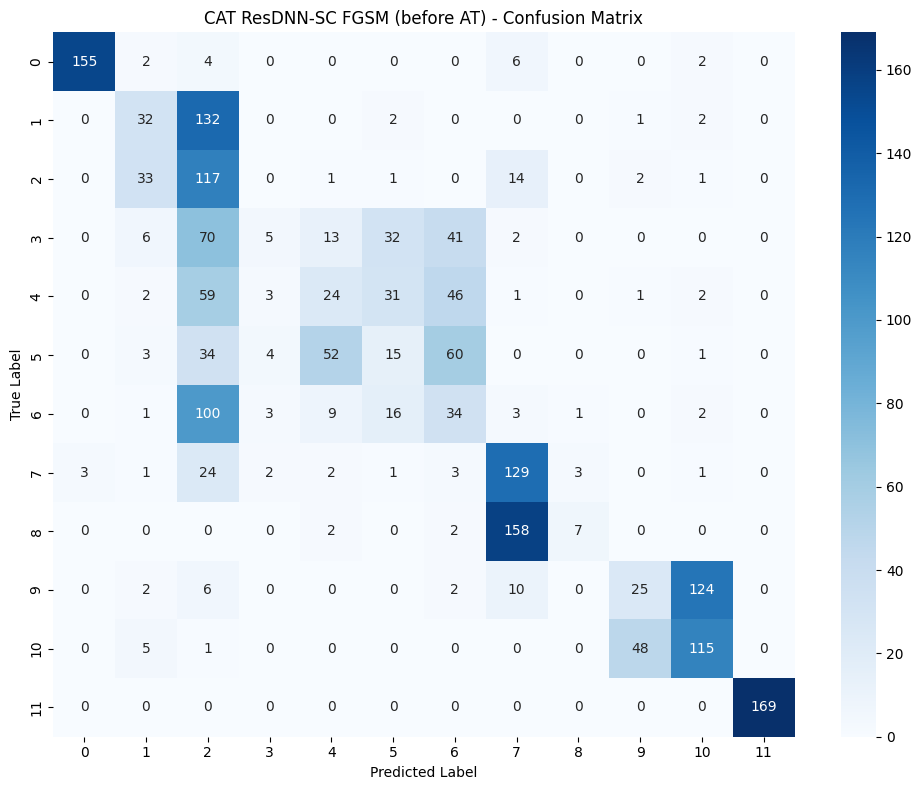

--- ResDNN-SC PGD (before AT) ---
Accuracy: 36.00%
Precision: 40.06%
Recall: 36.00%
F1 Score: 0.3307


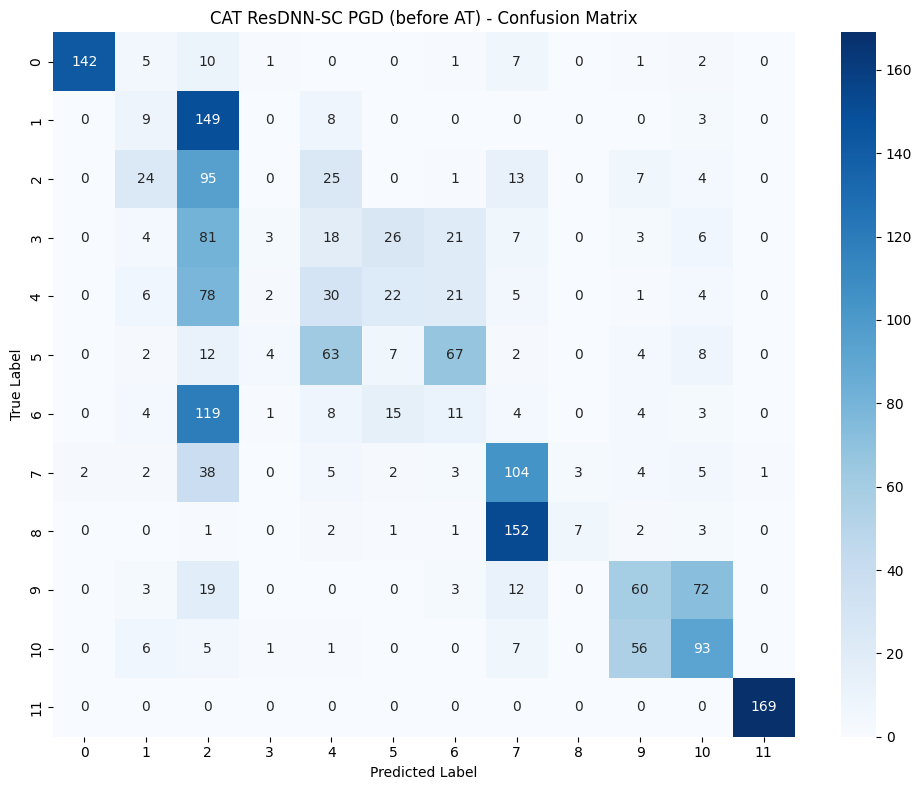

--- ResDNN-SC DEEPFOOL (before AT) ---
Accuracy: 16.57%
Precision: 24.14%
Recall: 16.57%
F1 Score: 0.1406


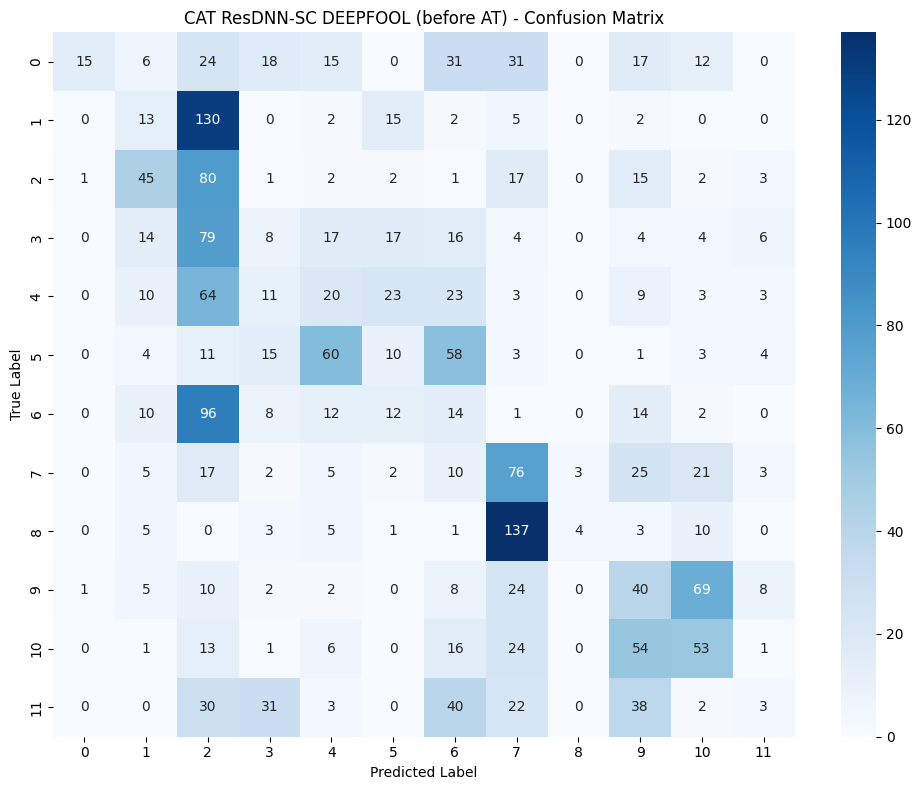

--- ResDNN-SC CW (before AT) ---
Accuracy: 79.04%
Precision: 79.20%
Recall: 79.04%
F1 Score: 0.7885


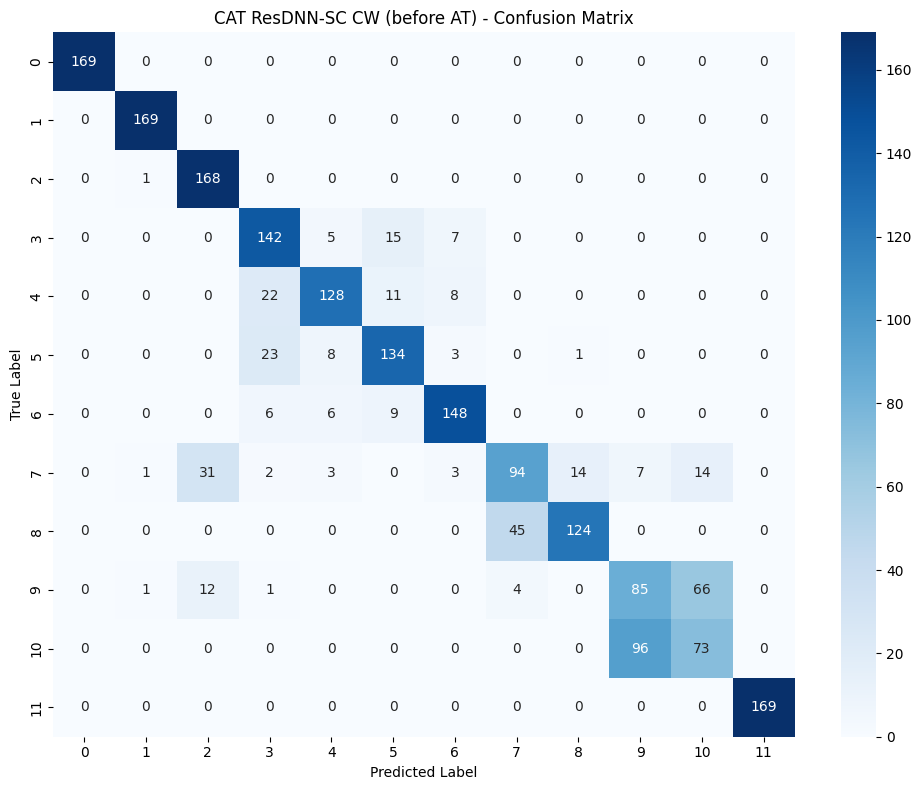

--- ResDNN-SC MIM (before AT) ---
Accuracy: 36.69%
Precision: 40.21%
Recall: 36.69%
F1 Score: 0.3403


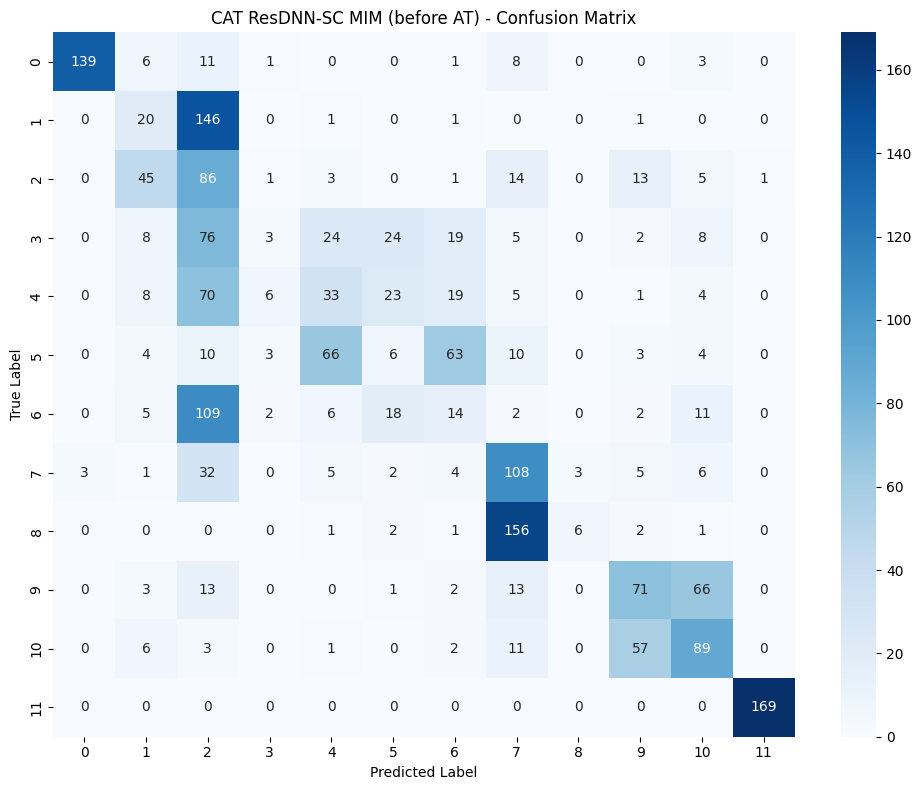

--- LSTM-SC FGSM (before AT) ---
Accuracy: 42.75%
Precision: 45.63%
Recall: 42.75%
F1 Score: 0.3894


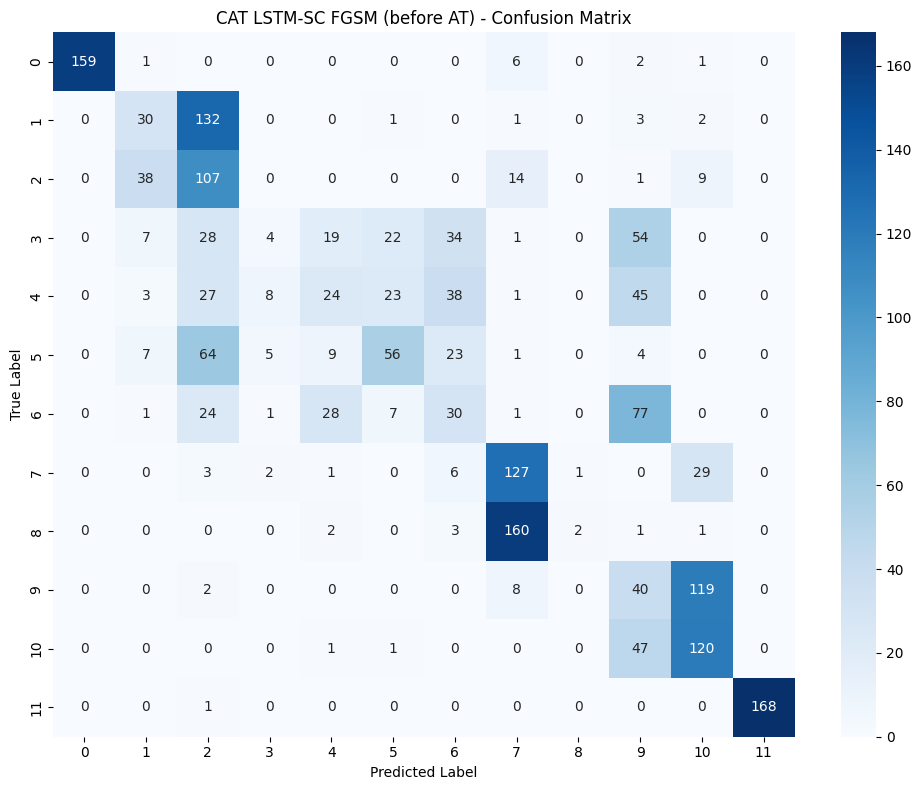

--- LSTM-SC PGD (before AT) ---
Accuracy: 41.67%
Precision: 40.05%
Recall: 41.67%
F1 Score: 0.3686


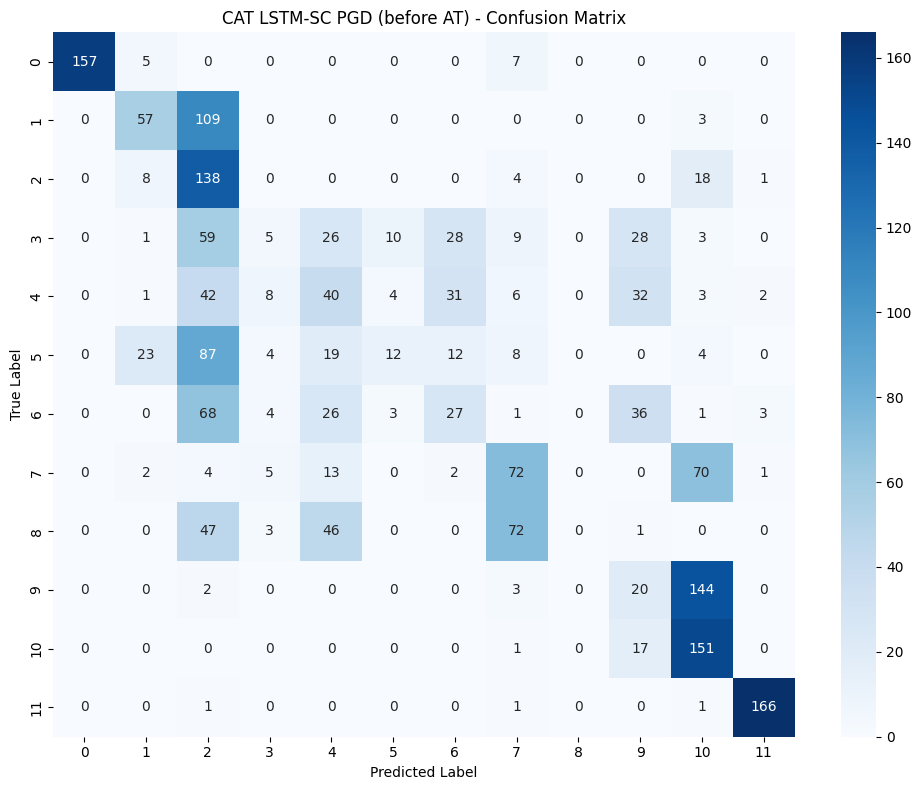

--- LSTM-SC DEEPFOOL (before AT) ---
Accuracy: 16.32%
Precision: 24.50%
Recall: 16.32%
F1 Score: 0.1550


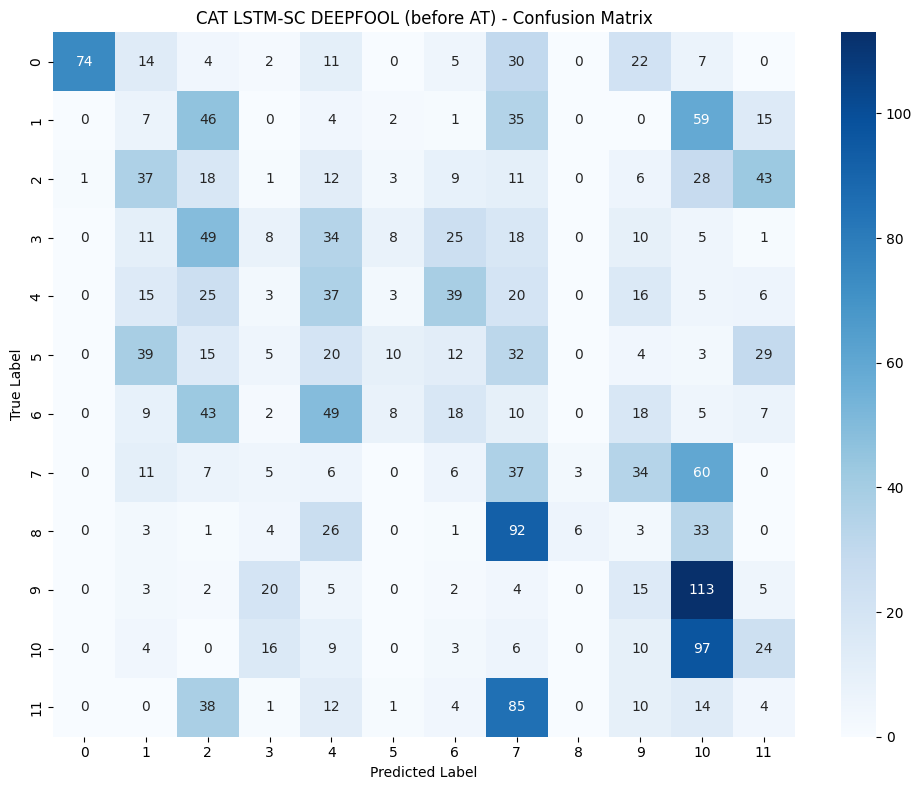

--- LSTM-SC CW (before AT) ---
Accuracy: 73.52%
Precision: 74.88%
Recall: 73.52%
F1 Score: 0.7274


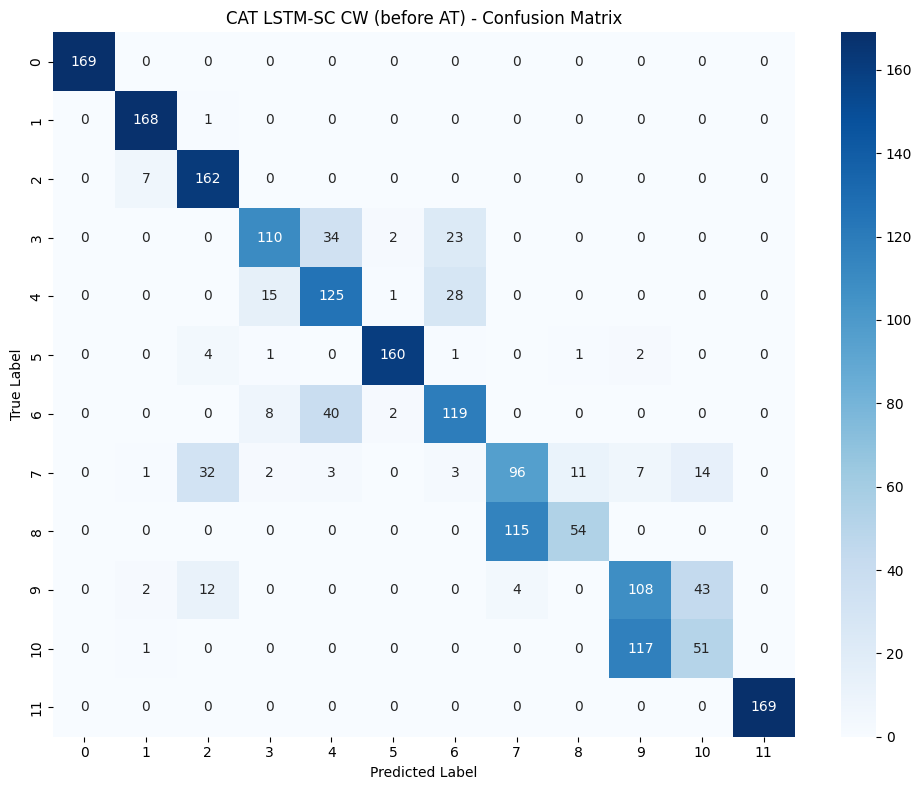

--- LSTM-SC MIM (before AT) ---
Accuracy: 39.00%
Precision: 43.55%
Recall: 39.00%
F1 Score: 0.3353


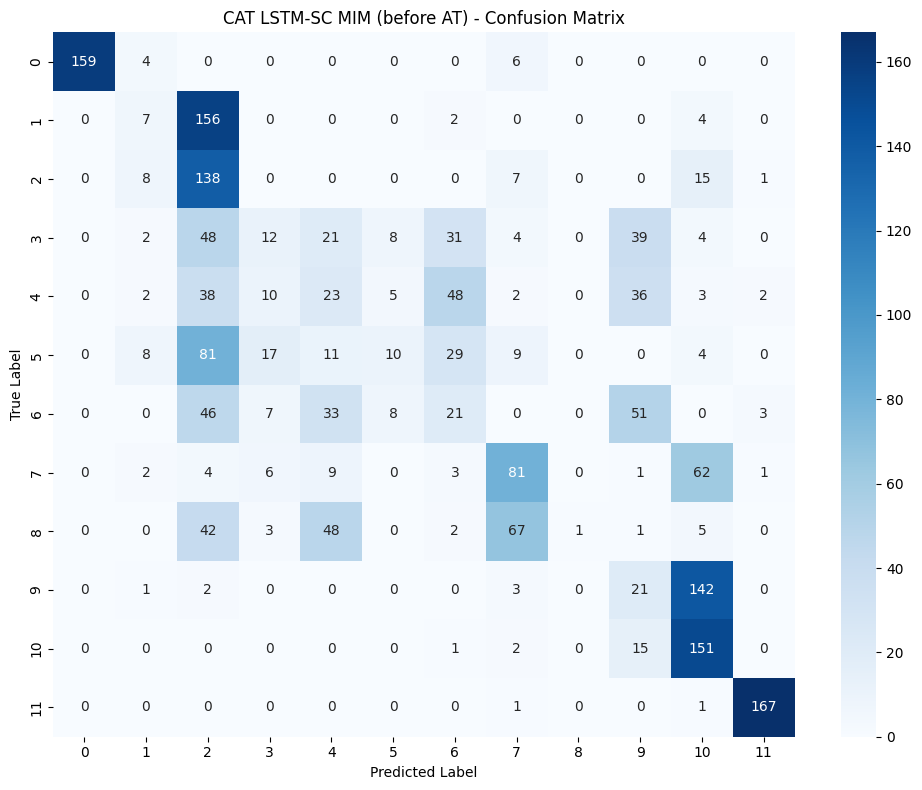

--- CAT ZOO (before AT) ---
Accuracy: 52.42%
Precision: 53.55%
Recall: 52.42%
F1 Score: 0.5260


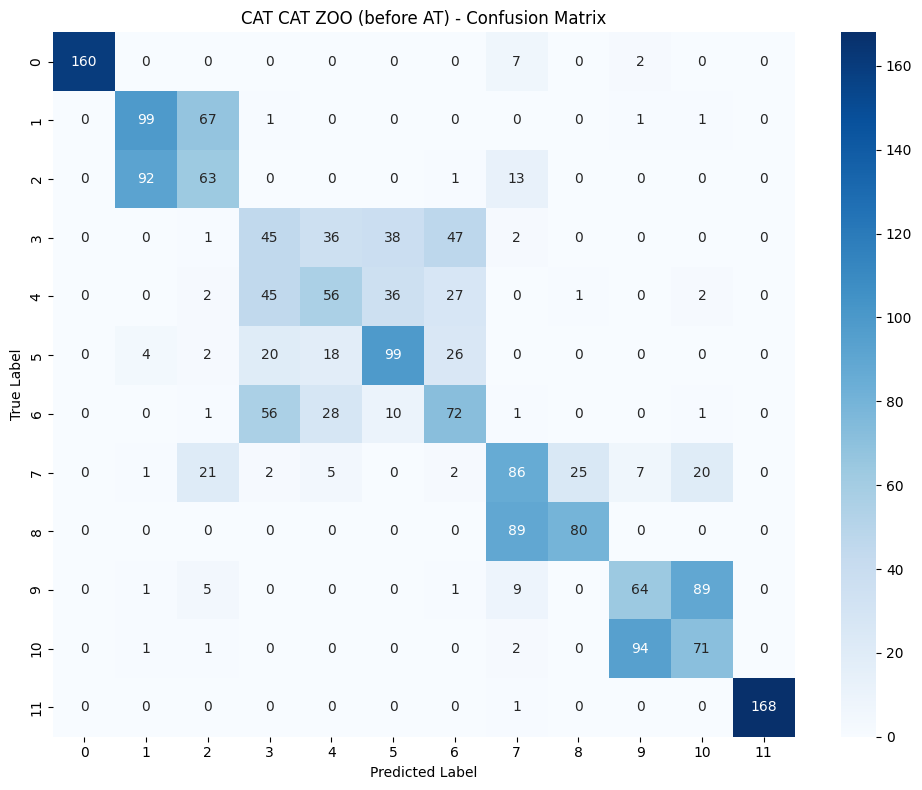

--- CAT HSJA (before AT) ---
Accuracy: 41.62%
Precision: 51.01%
Recall: 41.62%
F1 Score: 0.4243


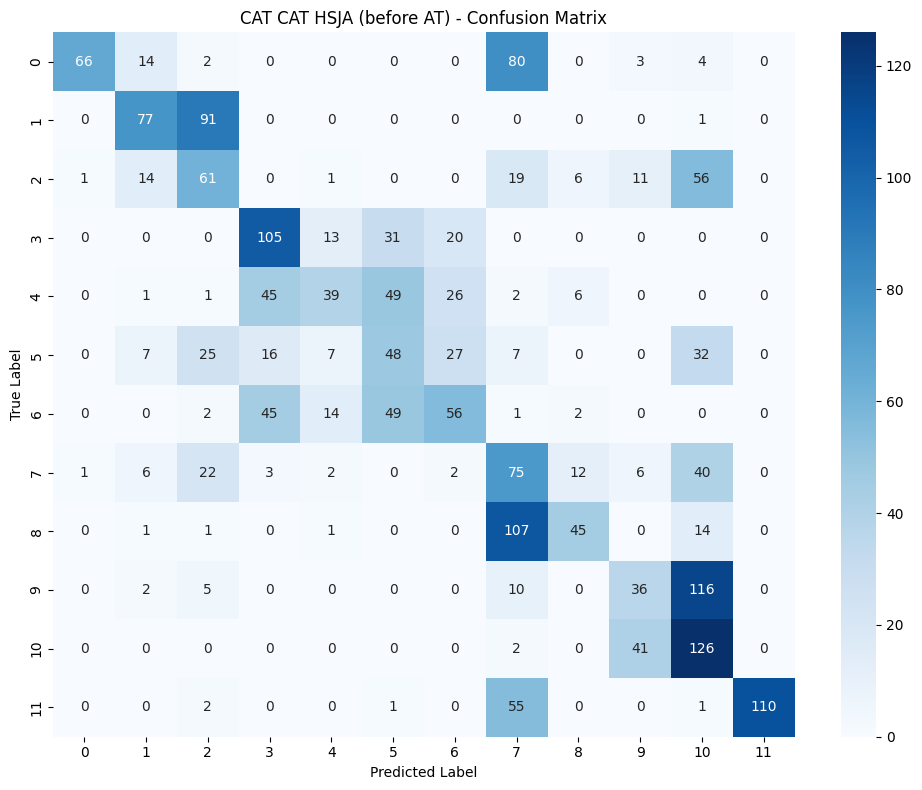

In [5]:
adv_eval_data = {}

# Source 1: ResDNN scaled-space WB eval adv
RESDNN_SC_DIR = '../../adv_samples/adv_eval/resdnn_sc'
for atk in ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']:
    path = os.path.join(RESDNN_SC_DIR, f'resdnn_{atk}_adv.csv')
    if os.path.exists(path):
        df_adv = pd.read_csv(path)
        adv_eval_data[f'resdnn_sc_{atk}'] = df_adv.drop(columns=['Label']).values.astype(np.float32)
        preds_adv = classifier.predict(adv_eval_data[f'resdnn_sc_{atk}'])
        evaluate_attack(y_test, preds_adv, f'ResDNN-SC {atk.upper()} (before AT)')
    else:
        print(f'[SKIP] {path}')

# Source 2: LSTM scaled-space WB eval adv
LSTM_SC_DIR = '../../adv_samples/adv_eval/lstm_sc'
for atk in ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']:
    path = os.path.join(LSTM_SC_DIR, f'lstm_{atk}_adv.csv')
    if os.path.exists(path):
        df_adv = pd.read_csv(path)
        adv_eval_data[f'lstm_sc_{atk}'] = df_adv.drop(columns=['Label']).values.astype(np.float32)
        preds_adv = classifier.predict(adv_eval_data[f'lstm_sc_{atk}'])
        evaluate_attack(y_test, preds_adv, f'LSTM-SC {atk.upper()} (before AT)')
    else:
        print(f'[SKIP] {path}')

# Source 3: CAT's own BB attacks (if available)
for atk in ['zoo', 'hsja']:
    path = f'../../../adv_samples/adv_eval/cat/cat_{atk}_adv.csv'
    if os.path.exists(path):
        df_adv = pd.read_csv(path)
        adv_eval_data[f'cat_{atk}'] = df_adv.drop(columns=['Label']).values.astype(np.float32)
        preds_adv = classifier.predict(adv_eval_data[f'cat_{atk}'])
        evaluate_attack(y_test, preds_adv, f'CAT {atk.upper()} (before AT)')
    else:
        print(f'[SKIP] {path}')

### 4. Load ResDNN scaled-space adv training data

In [6]:
df_train = pd.read_csv('../../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values.astype(np.float32)
y_train = df_train['Label'].values.astype(int)

# AT source 1: ResDNN scaled-space
ADV_SC_DIR = '../../adv_samples/adv_training/resdnn_sc'

# AT source 2: LSTM scaled-space (cross-model diversity)
LSTM_SC_DIR = '../../adv_samples/adv_training/lstm_sc'

# (source, prefix, attack_name, weight)
ALL_SOURCES = [
    # ResDNN
    (ADV_SC_DIR,  'resdnn', 'fgsm',     5.0),
    (ADV_SC_DIR,  'resdnn', 'pgd',      5.0),
    (ADV_SC_DIR,  'resdnn', 'deepfool', 2.5),
    (ADV_SC_DIR,  'resdnn', 'cw',       4.5),
    (ADV_SC_DIR,  'resdnn', 'zoo',      1.0),
    (ADV_SC_DIR,  'resdnn', 'hsja',     1.0),
    (ADV_SC_DIR,  'resdnn', 'mim',      2.5),
    # LSTM
    # (LSTM_SC_DIR, 'lstm',   'fgsm',     5.0),
    # (LSTM_SC_DIR, 'lstm',   'pgd',      5.0),
    # (LSTM_SC_DIR, 'lstm',   'deepfool', 2.5),
    # (LSTM_SC_DIR, 'lstm',   'mim',      2.5),
]

CLEAN_ADV_RATIO = 0.1
n_clean = len(X_train)
n_adv_budget = int(n_clean / CLEAN_ADV_RATIO)
total_weight = sum(w for _, _, _, w in ALL_SOURCES)

rng = np.random.RandomState(42)
parts_X, parts_y = [], []

print(f'Budget: {n_adv_budget} (clean={n_clean}, ratio={CLEAN_ADV_RATIO})\n')

for src_dir, prefix, atk_name, weight in ALL_SOURCES:
    path = os.path.join(src_dir, f'{prefix}_{atk_name}_train_adv.csv')
    if not os.path.exists(path):
        print(f'  [SKIP] {path}')
        continue

    df = pd.read_csv(path)
    X_atk = df.drop(columns=['Label']).values.astype(np.float32)
    y_atk = df['Label'].values.astype(int)

    n_sample = int(n_adv_budget * weight / total_weight)
    n_sample = min(n_sample, len(X_atk))
    idx = rng.choice(len(X_atk), size=n_sample, replace=len(X_atk) < n_sample)
    parts_X.append(X_atk[idx])
    parts_y.append(y_atk[idx])
    print(f'  {prefix}_{atk_name:>10s}: {len(X_atk)} -> {n_sample}  (weight={weight})')

# Merge & dedup
adv_X = np.concatenate(parts_X)
adv_y = np.concatenate(parts_y)

X_train_at = np.concatenate([X_train, adv_X])
y_train_at = np.concatenate([y_train, adv_y])

df_tmp = pd.DataFrame(X_train_at)
df_tmp['_lbl'] = y_train_at
n_before = len(df_tmp)
df_tmp = df_tmp.drop_duplicates()
X_train_at = df_tmp.drop(columns=['_lbl']).values.astype(np.float32)
y_train_at = df_tmp['_lbl'].values.astype(int)

print(f'\nClean: {n_clean} | Adv: {len(adv_X)} | Dedup: {n_before - len(df_tmp)}')
print(f'AT train: {X_train_at.shape}')
print(f'\nLabel distribution:\n{pd.Series(y_train_at).value_counts().sort_index()}')

Budget: 96000 (clean=9600, ratio=0.1)

  resdnn_      fgsm: 9600 -> 9600  (weight=5.0)
  resdnn_       pgd: 9600 -> 9600  (weight=5.0)
  resdnn_  deepfool: 9600 -> 9600  (weight=2.5)
  resdnn_        cw: 9600 -> 9600  (weight=4.5)
  [SKIP] ../../adv_samples/adv_training/resdnn_sc/resdnn_zoo_train_adv.csv
  [SKIP] ../../adv_samples/adv_training/resdnn_sc/resdnn_hsja_train_adv.csv
  resdnn_       mim: 9600 -> 9600  (weight=2.5)

Clean: 9600 | Adv: 48000 | Dedup: 92
AT train: (57508, 66)

Label distribution:
0     4748
1     4798
2     4793
3     4799
4     4799
5     4800
6     4800
7     4799
8     4799
9     4798
10    4799
11    4776
Name: count, dtype: int64


### 5. Retrain CatBoost

In [7]:
print('CatBoost adversarial training (ResDNN scaled-space)...')

cat_params = {
    'iterations': 5000,
    'depth': 8,
    'learning_rate': 0.05,
    'l2_leaf_reg': 3,
    'loss_function': 'MultiClass',
    'task_type': 'CPU',
    'thread_count': -1,
    'random_seed': 42,
    'eval_metric': 'TotalF1',
    'od_type': 'Iter',
    'od_wait': 50,
}

cat_model_at = CatBoostClassifier(**cat_params)
cat_model_at.fit(X_train_at, y_train_at, plot=False)
print('Done.')

os.makedirs('../../../defense/exp/models', exist_ok=True)
joblib.dump(cat_model_at, '../../../defense/exp/models/framework_cat_TVAE_at_resdnn_sc.pkl')
print('Saved to defense/exp/models/framework_cat_TVAE_at_resdnn_sc.pkl')

CatBoost adversarial training (ResDNN scaled-space)...
0:	learn: 0.5997373	total: 301ms	remaining: 25m 6s
1:	learn: 0.6315073	total: 484ms	remaining: 20m 8s
2:	learn: 0.6450560	total: 734ms	remaining: 20m 22s
3:	learn: 0.6560045	total: 877ms	remaining: 18m 15s
4:	learn: 0.6593939	total: 1.03s	remaining: 17m 13s
5:	learn: 0.6670405	total: 1.17s	remaining: 16m 17s
6:	learn: 0.6720572	total: 1.4s	remaining: 16m 40s
7:	learn: 0.6745211	total: 1.71s	remaining: 17m 47s
8:	learn: 0.6773951	total: 1.89s	remaining: 17m 25s
9:	learn: 0.6737586	total: 2.02s	remaining: 16m 47s
10:	learn: 0.6772989	total: 2.15s	remaining: 16m 13s
11:	learn: 0.6783421	total: 2.28s	remaining: 15m 48s
12:	learn: 0.6804978	total: 2.45s	remaining: 15m 41s
13:	learn: 0.6827665	total: 2.67s	remaining: 15m 51s
14:	learn: 0.6856357	total: 2.81s	remaining: 15m 34s
15:	learn: 0.6864292	total: 3.05s	remaining: 15m 50s
16:	learn: 0.6864697	total: 3.18s	remaining: 15m 32s
17:	learn: 0.6879641	total: 3.32s	remaining: 15m 19s
18:	

In [119]:
joblib.dump(cat_model_at, '../../../defense/exp/models/framework_cat_TVAE_at.pkl')

['../../../defense/exp/models/framework_cat_TVAE_at.pkl']

### 6. Evaluate retrained model

--- Original (after AT) ---
Accuracy: 83.38%
Precision: 83.21%
Recall: 83.38%
F1 Score: 0.8316


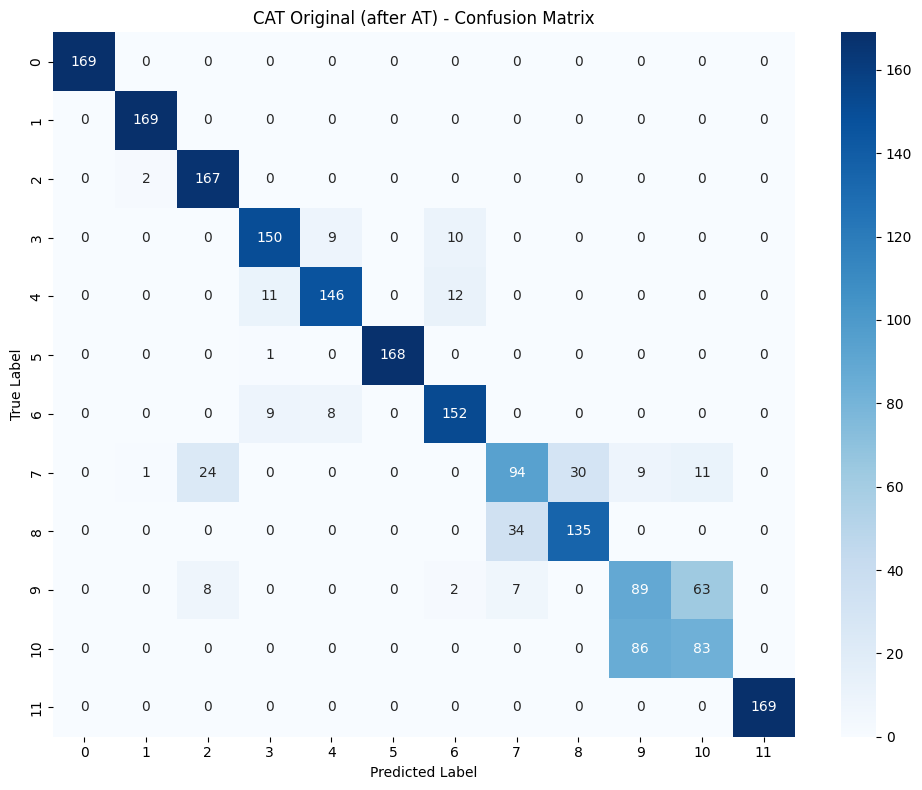

--- RESDNN_SC_FGSM (after AT) ---
Accuracy: 81.46%
Precision: 81.36%
Recall: 81.46%
F1 Score: 0.8123


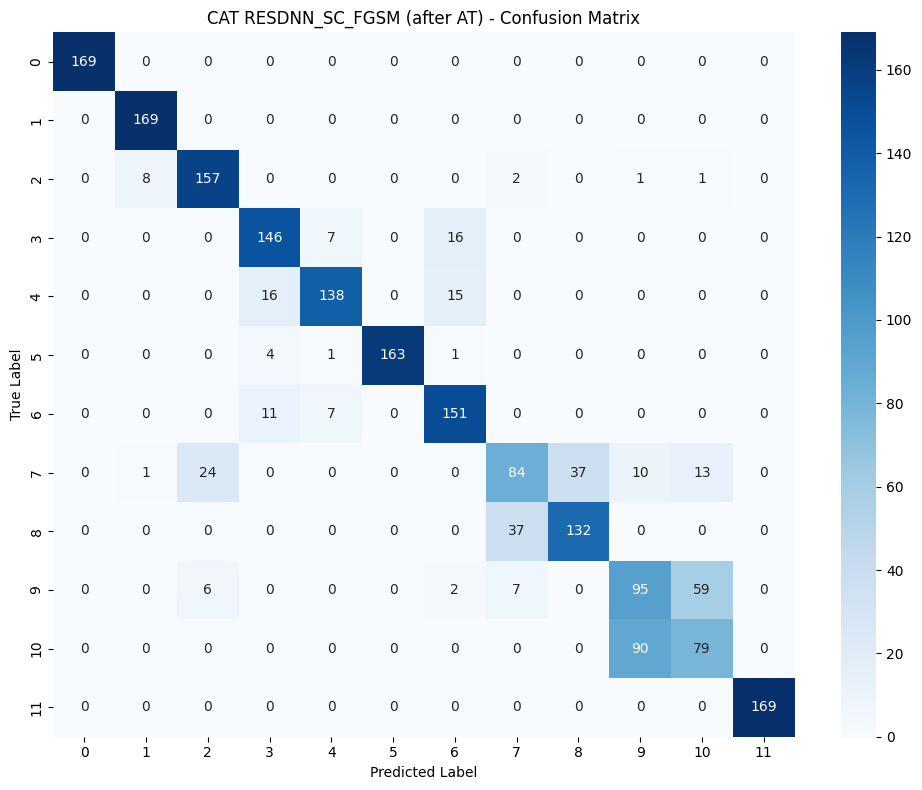

--- RESDNN_SC_PGD (after AT) ---
Accuracy: 84.96%
Precision: 84.87%
Recall: 84.96%
F1 Score: 0.8475


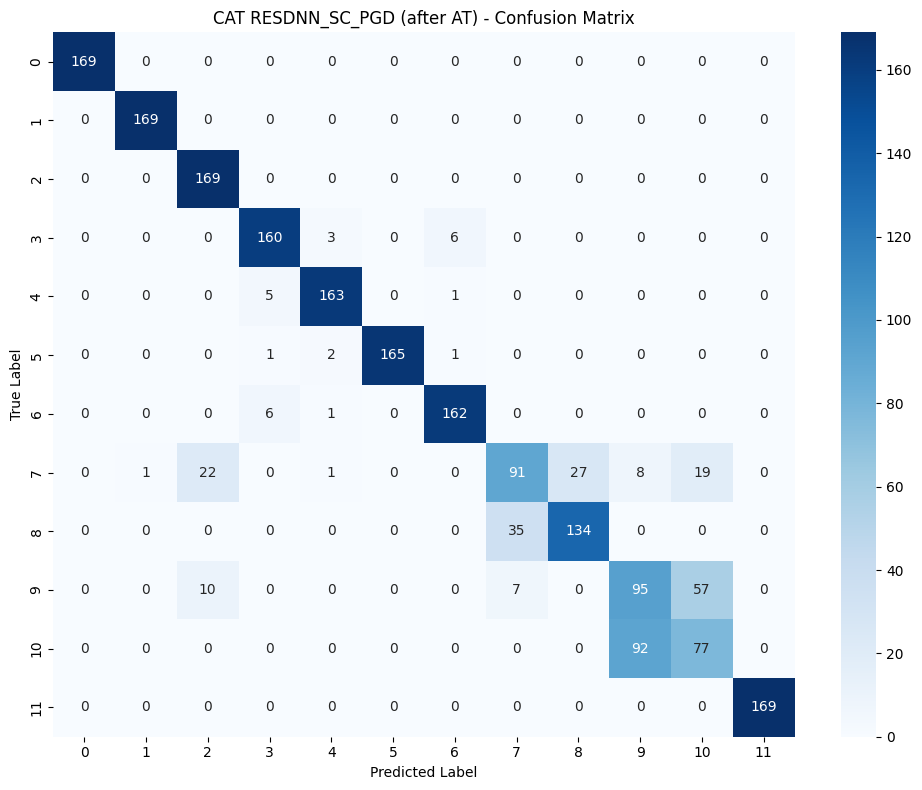

--- RESDNN_SC_DEEPFOOL (after AT) ---
Accuracy: 77.22%
Precision: 77.29%
Recall: 77.22%
F1 Score: 0.7708


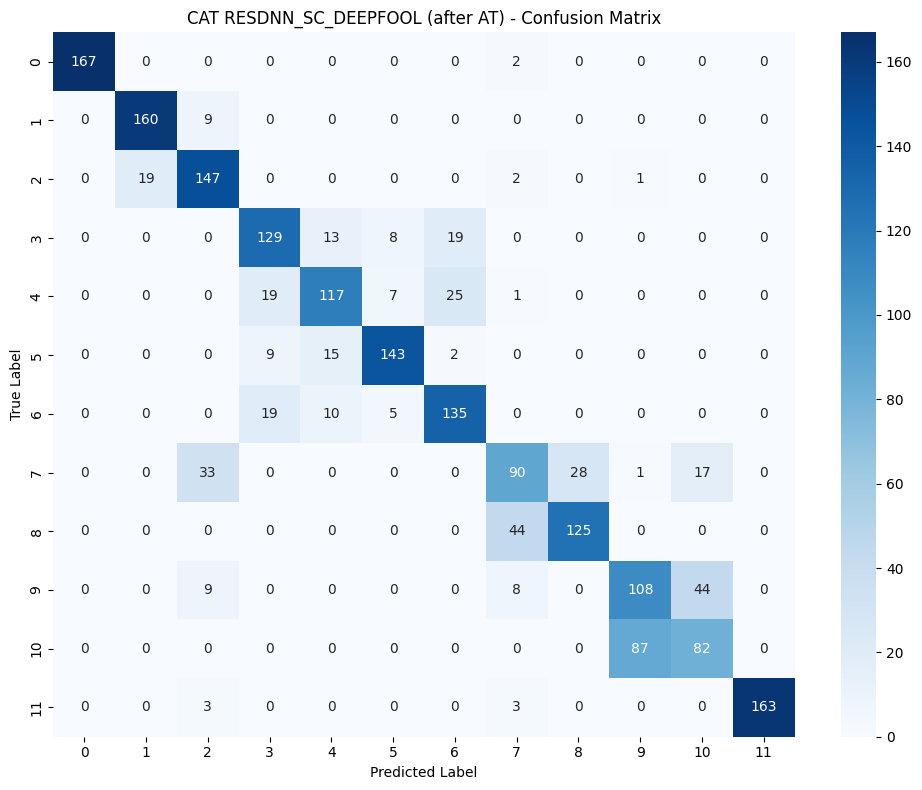

--- RESDNN_SC_CW (after AT) ---
Accuracy: 80.23%
Precision: 80.32%
Recall: 80.23%
F1 Score: 0.8006


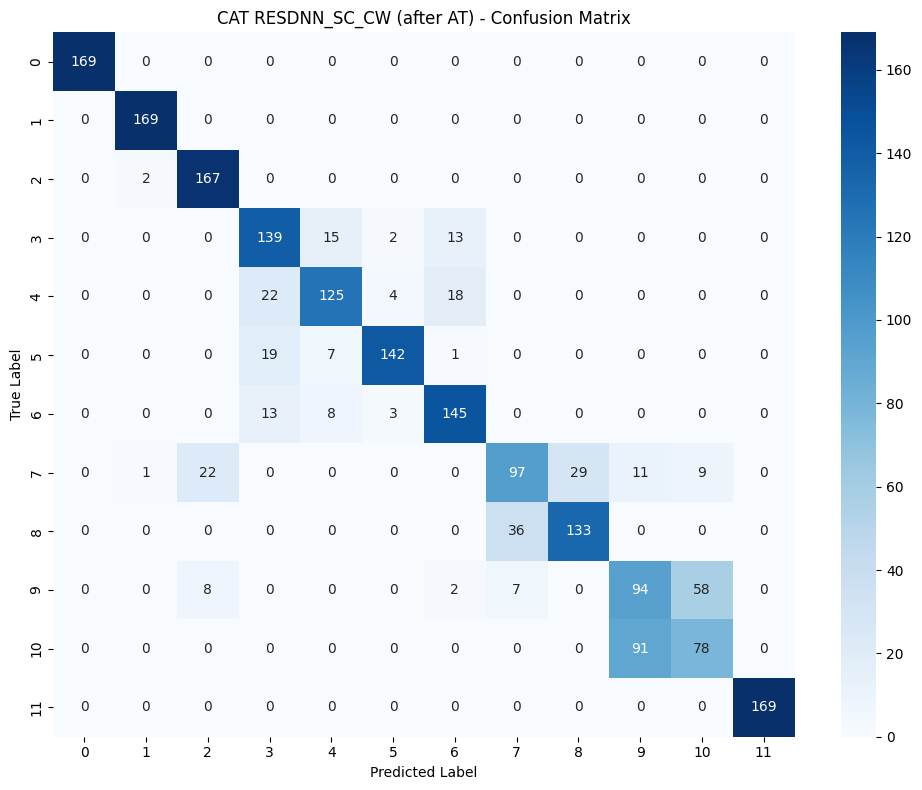

--- RESDNN_SC_MIM (after AT) ---
Accuracy: 80.33%
Precision: 80.41%
Recall: 80.33%
F1 Score: 0.8019


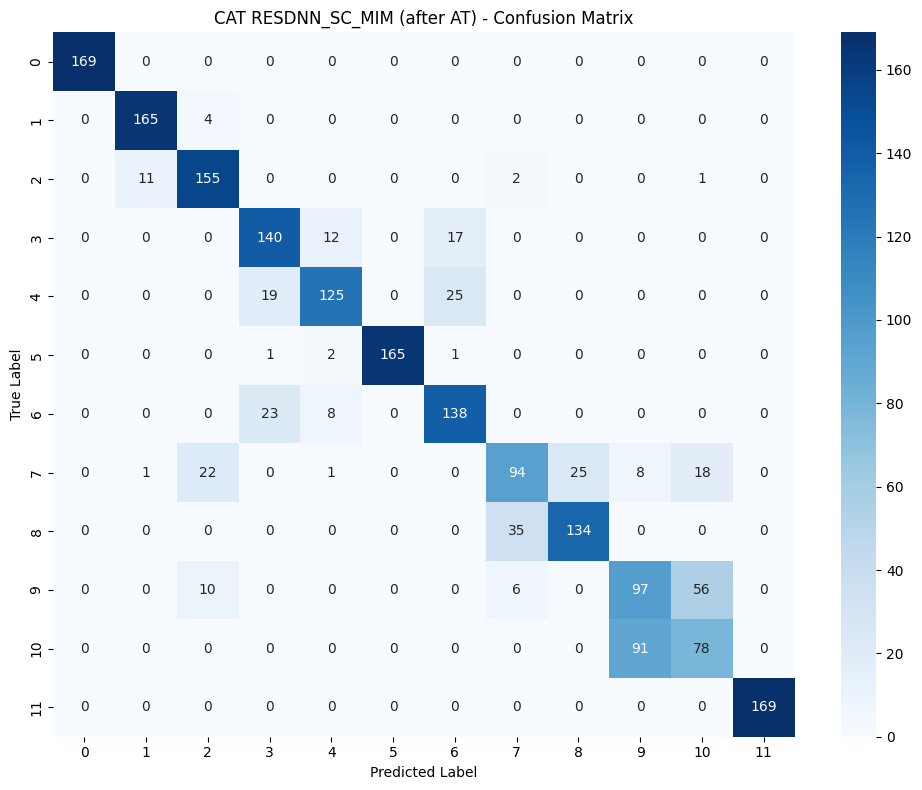

--- LSTM_SC_FGSM (after AT) ---
Accuracy: 72.63%
Precision: 72.53%
Recall: 72.63%
F1 Score: 0.7238


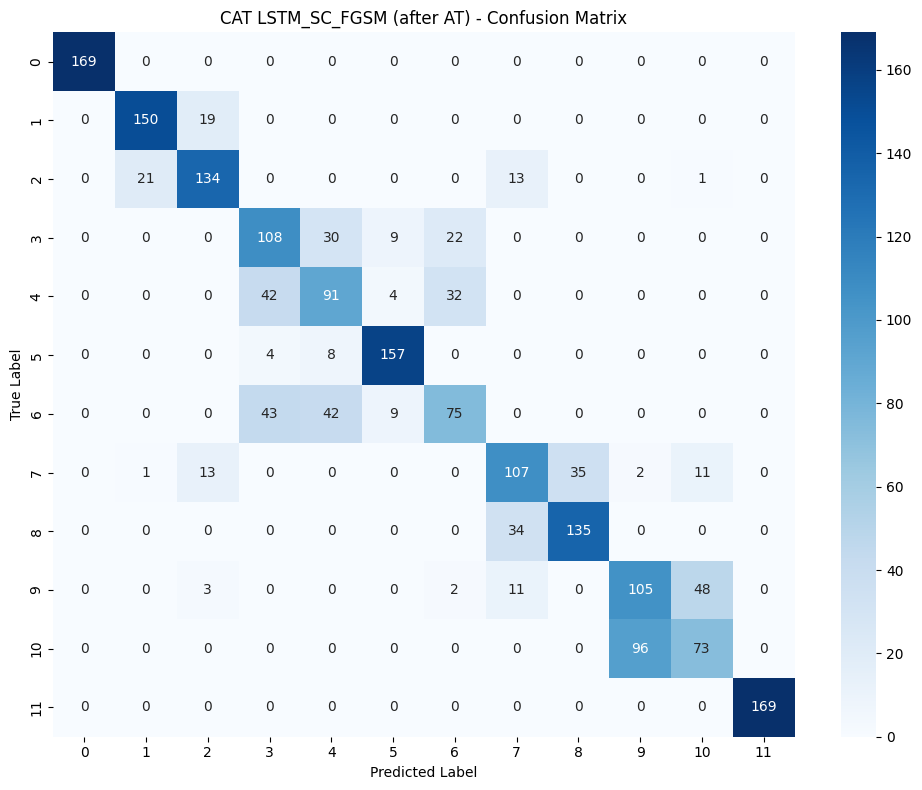

--- LSTM_SC_PGD (after AT) ---
Accuracy: 81.02%
Precision: 80.90%
Recall: 81.02%
F1 Score: 0.8070


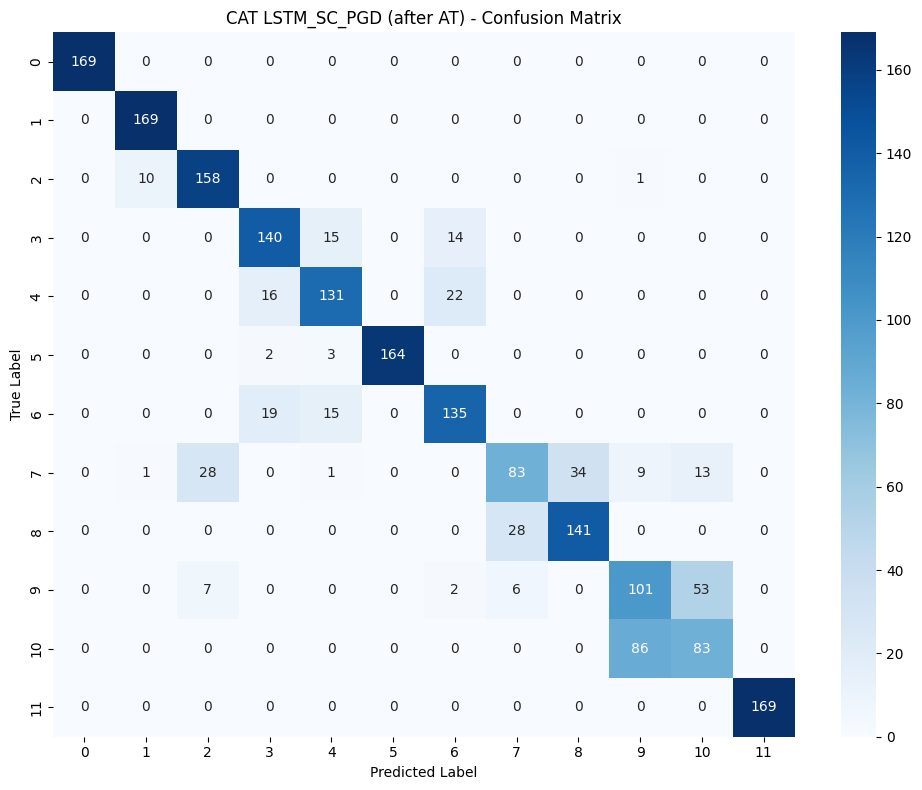

--- LSTM_SC_DEEPFOOL (after AT) ---
Accuracy: 68.69%
Precision: 68.62%
Recall: 68.69%
F1 Score: 0.6832


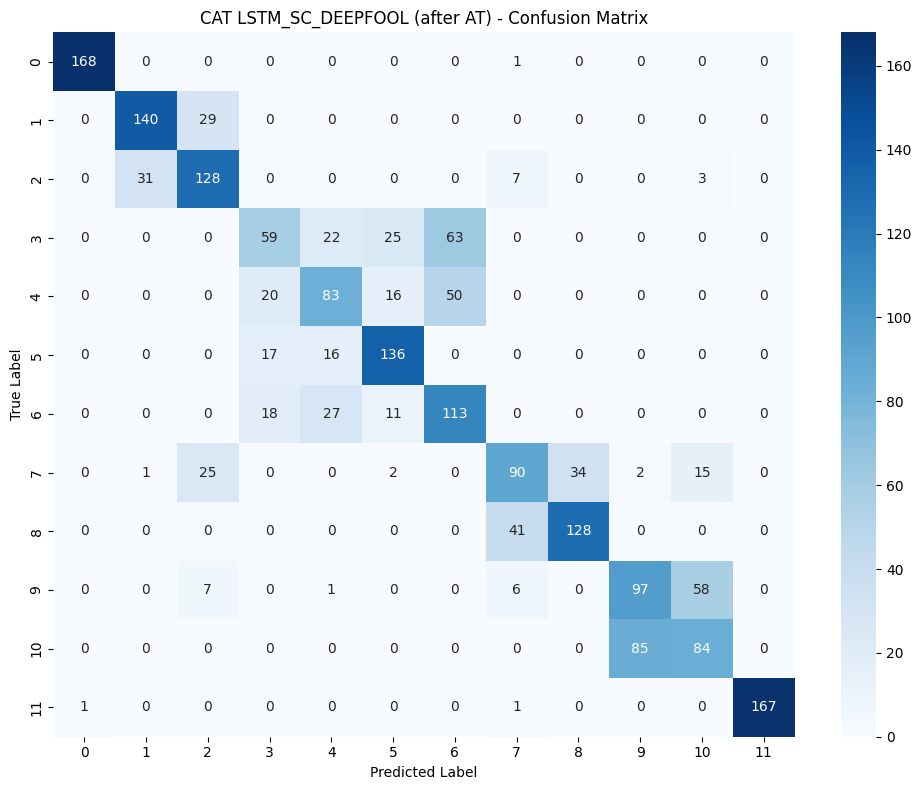

--- LSTM_SC_CW (after AT) ---
Accuracy: 78.99%
Precision: 79.54%
Recall: 78.99%
F1 Score: 0.7870


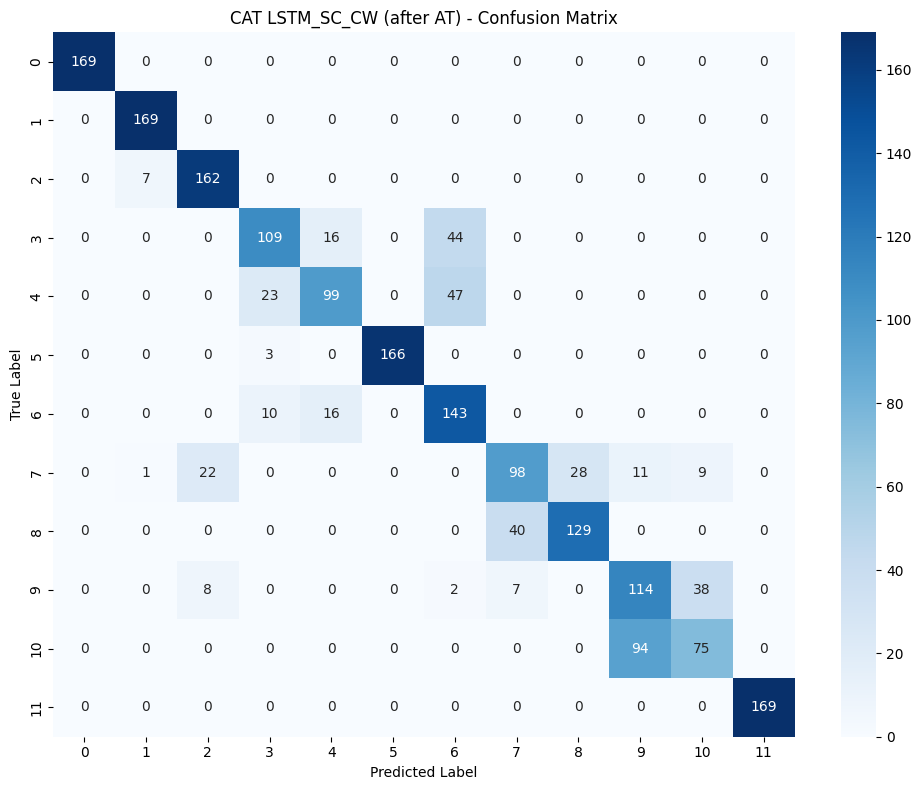

--- LSTM_SC_MIM (after AT) ---
Accuracy: 79.49%
Precision: 79.35%
Recall: 79.49%
F1 Score: 0.7920


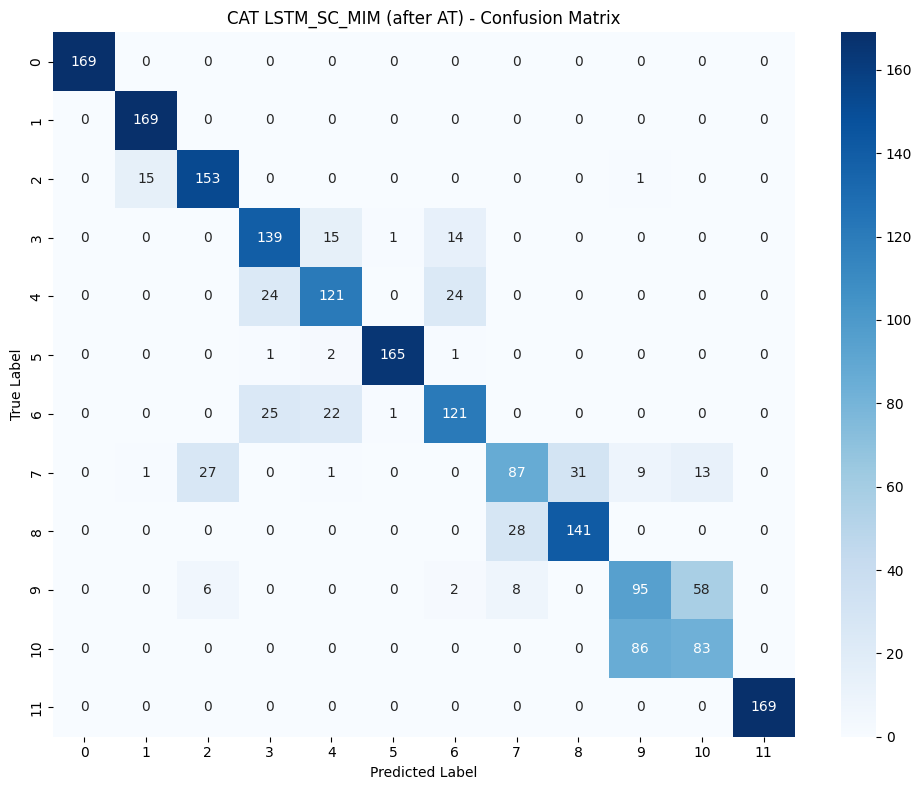

--- CAT_ZOO (after AT) ---
Accuracy: 51.28%
Precision: 51.74%
Recall: 51.28%
F1 Score: 0.5122


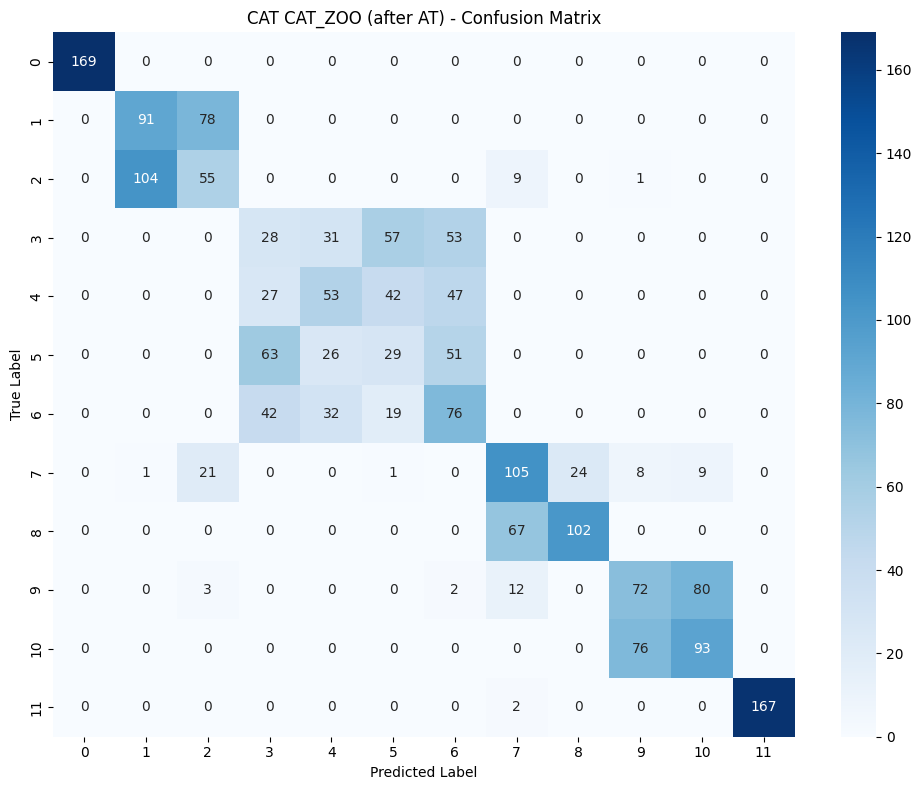

--- CAT_HSJA (after AT) ---
Accuracy: 62.52%
Precision: 65.47%
Recall: 62.52%
F1 Score: 0.6169


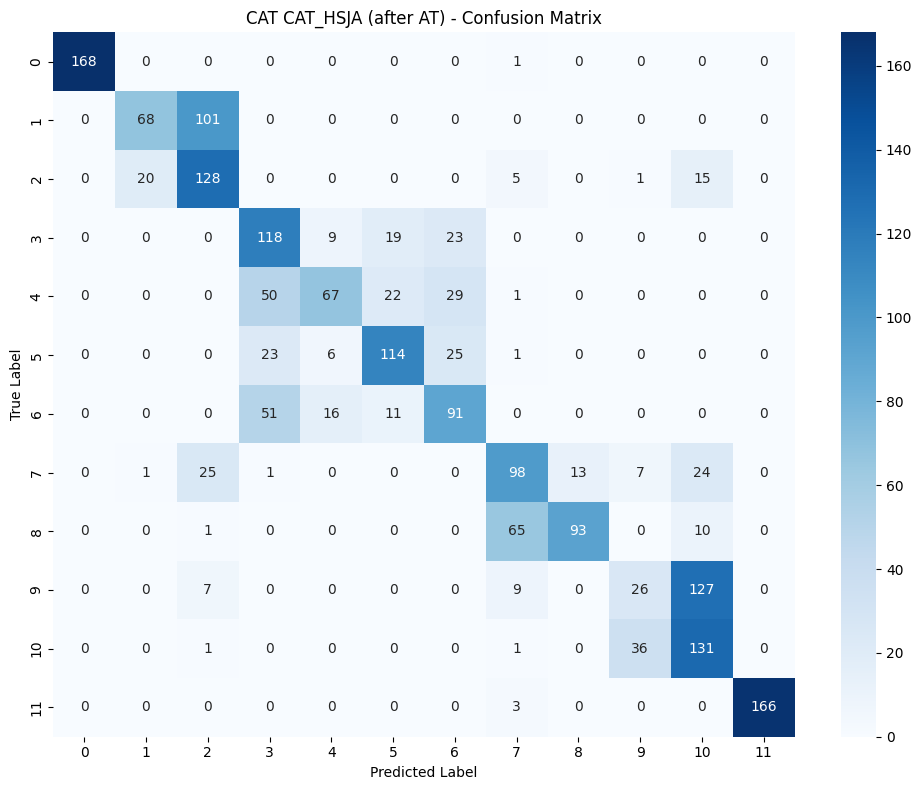

In [154]:
cat_model_at = joblib.load('../../../defense/exp/models/framework_cat_TVAE_at_resdnn_sc.pkl')

classifier_at = CatBoostARTClassifier(
    model=cat_model_at,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
)

# Clean test
preds_orig = classifier_at.predict(X_test)
evaluate_attack(y_test, preds_orig, 'Original (after AT)')

# All adv eval sets
for atk_key, adv_data in adv_eval_data.items():
    preds_adv = classifier_at.predict(adv_data)
    evaluate_attack(y_test, preds_adv, f'{atk_key.upper()} (after AT)')

### 7. ASR comparison

In [155]:
# Before AT
preds_before = classifier.predict(X_test)
y_pred_before = np.argmax(preds_before, axis=1)
correct_before = np.where(y_test == y_pred_before)[0]

# After AT
preds_after = classifier_at.predict(X_test)
y_pred_after = np.argmax(preds_after, axis=1)
correct_after = np.where(y_test == y_pred_after)[0]

print('=== CatBoost ASR: ResDNN Scaled-Space AT (Before -> After) ===')
print(f'Clean Accuracy: {accuracy_score(y_test, y_pred_before)*100:.2f}% -> {accuracy_score(y_test, y_pred_after)*100:.2f}%')
print()

for atk_key, adv_data in adv_eval_data.items():
    preds_adv_b = np.argmax(classifier.predict(adv_data), axis=1)
    asr_before = np.sum(y_pred_before[correct_before] != preds_adv_b[correct_before]) / len(correct_before) * 100

    preds_adv_a = np.argmax(classifier_at.predict(adv_data), axis=1)
    asr_after = np.sum(y_pred_after[correct_after] != preds_adv_a[correct_after]) / len(correct_after) * 100

    acc_b = accuracy_score(y_test, preds_adv_b) * 100
    acc_a = accuracy_score(y_test, preds_adv_a) * 100

    print(f'{atk_key.upper():>18s}  Acc: {acc_b:.2f}% -> {acc_a:.2f}%  |  ASR: {asr_before:.2f}% -> {asr_after:.2f}%')

=== CatBoost ASR: ResDNN Scaled-Space AT (Before -> After) ===
Clean Accuracy: 86.34% -> 83.38%

    RESDNN_SC_FGSM  Acc: 40.83% -> 81.46%  |  ASR: 60.19% -> 6.62%
     RESDNN_SC_PGD  Acc: 32.30% -> 84.96%  |  ASR: 70.36% -> 3.90%
RESDNN_SC_DEEPFOOL  Acc: 19.48% -> 77.22%  |  ASR: 84.29% -> 14.78%
      RESDNN_SC_CW  Acc: 81.31% -> 80.23%  |  ASR: 6.51% -> 5.03%
     RESDNN_SC_MIM  Acc: 33.19% -> 80.33%  |  ASR: 68.99% -> 8.10%
      LSTM_SC_FGSM  Acc: 45.27% -> 72.63%  |  ASR: 55.51% -> 17.33%
       LSTM_SC_PGD  Acc: 45.86% -> 81.02%  |  ASR: 53.46% -> 7.04%
  LSTM_SC_DEEPFOOL  Acc: 23.92% -> 68.69%  |  ASR: 77.84% -> 23.48%
        LSTM_SC_CW  Acc: 77.81% -> 78.99%  |  ASR: 13.25% -> 8.28%
       LSTM_SC_MIM  Acc: 45.22% -> 79.49%  |  ASR: 54.65% -> 8.75%
           CAT_ZOO  Acc: 27.27% -> 51.28%  |  ASR: 81.44% -> 43.82%
          CAT_HSJA  Acc: 10.70% -> 62.52%  |  ASR: 95.49% -> 30.04%
